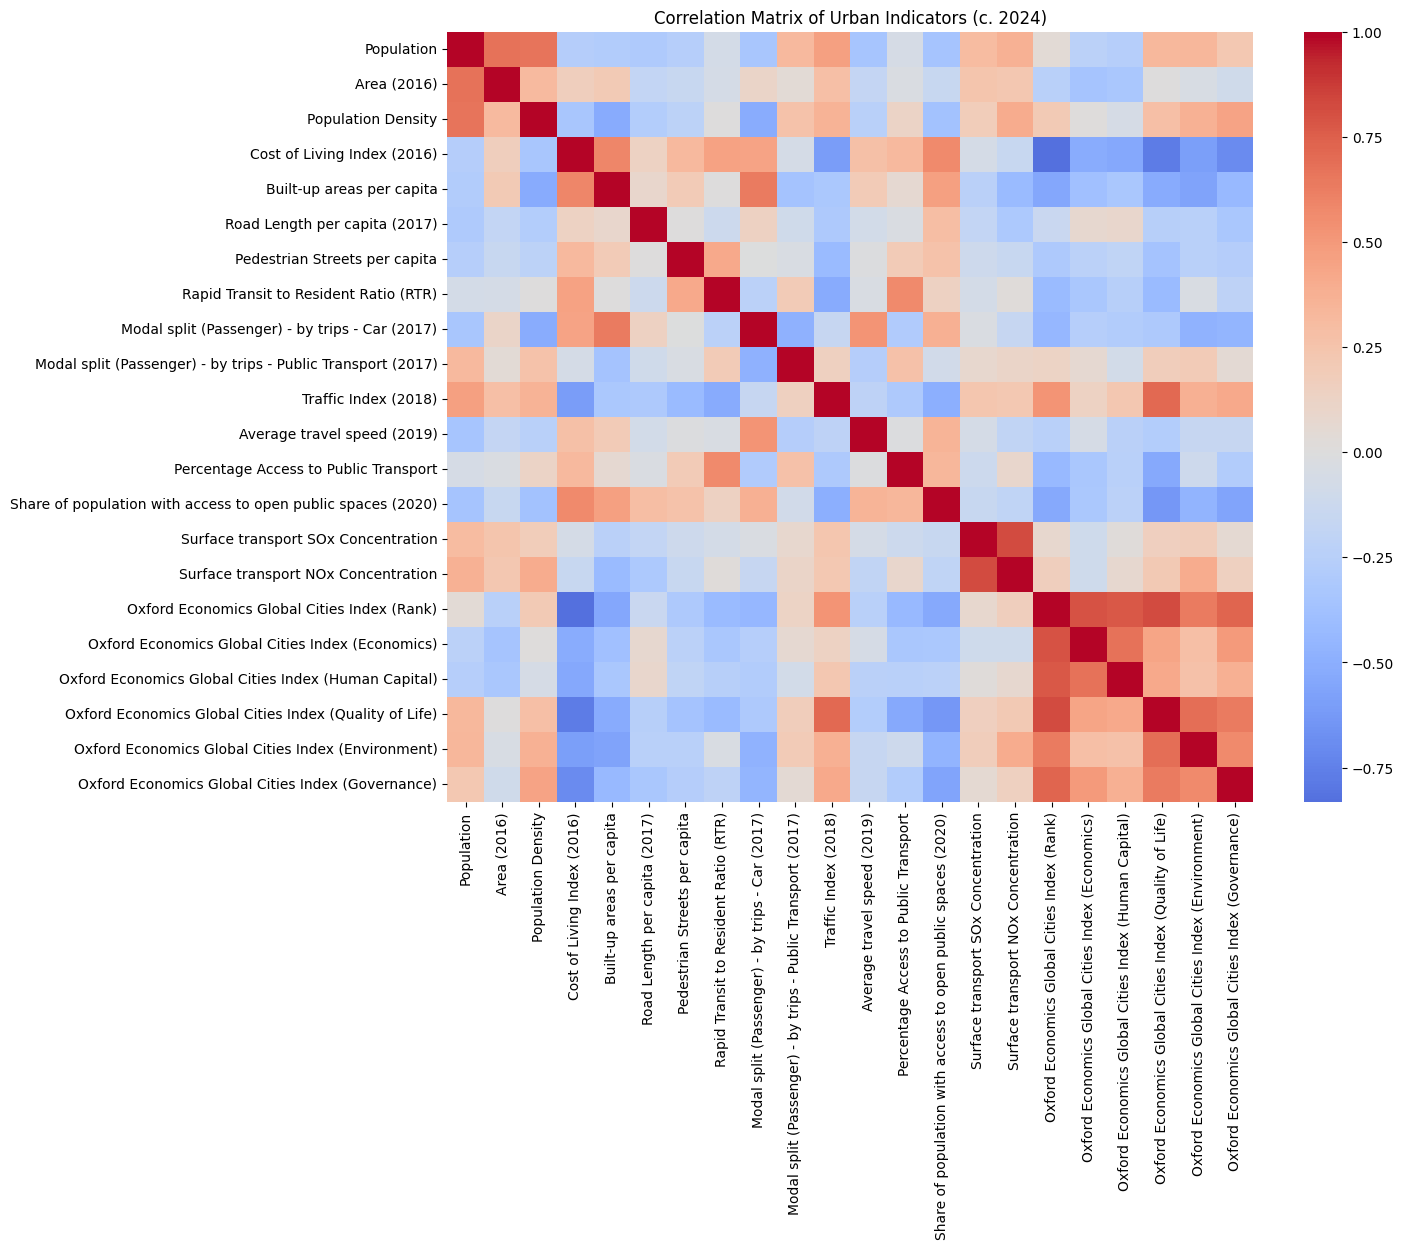

In [1]:
import pandas as pd

df = pd.read_csv('cleaned.csv')
df.set_index('Urban Center', inplace=True)
corr = df.corr(numeric_only=True)

#corr_pairs = corr.unstack()
#corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
#corr_pairs = corr_pairs.drop_duplicates()
#strong_pairs = corr_pairs[abs(corr_pairs) >= 0.7]
#strong_pairs = strong_pairs.sort_values(key=abs, ascending=False)
#print(strong_pairs)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Urban Indicators (c. 2024)")
plt.show()  

C:\Users\honwi\AppData\Local\Temp\ipykernel_9984\3284761874.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  den_acc_pt['Percentage Access to Public Transport'] *= 100
C:\Users\honwi\AppData\Local\Temp\ipykernel_9984\3284761874.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  den_a

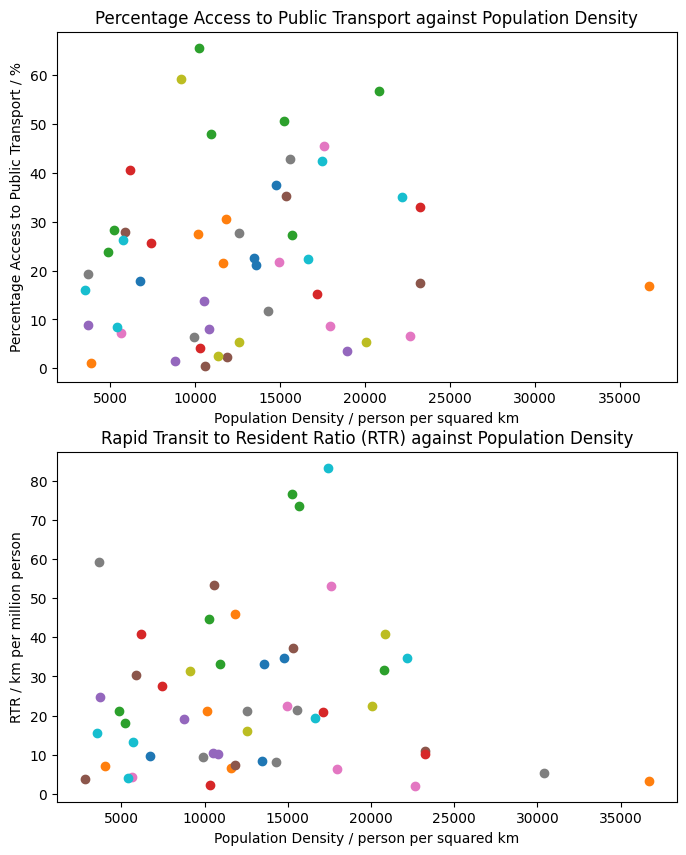

In [2]:
# 1a. Study density , percentage access to public transport, RTR
import numpy as np 

den_acc_pt = df[['Population Density', 'Percentage Access to Public Transport', 'Rapid Transit to Resident Ratio (RTR)']]
den_acc_pt['Percentage Access to Public Transport'] *= 100 

# drop rows with missing values 
den_acc_pt['Percentage Access to Public Transport'].replace(0, np.nan, inplace=True)
cleaned = den_acc_pt[den_acc_pt['Percentage Access to Public Transport'].notna() &
                     den_acc_pt['Rapid Transit to Resident Ratio (RTR)'].notna()]

# 1b. Plot 2 scatter (access vs density, RTR vs density)
fig, ax = plt.subplots(2, figsize=(8,10))
for i, row in den_acc_pt.iterrows():
    ax[0].scatter(row.iloc[0], row.iloc[1])
    ax[1].scatter(row.iloc[0], row.iloc[2])
        
ax[0].set_title("Percentage Access to Public Transport against Population Density")
ax[0].set_xlabel('Population Density / person per squared km')
ax[0].set_ylabel('Percentage Access to Public Transport / %')

ax[1].set_title("Rapid Transit to Resident Ratio (RTR) against Population Density")
ax[1].set_xlabel('Population Density / person per squared km')
ax[1].set_ylabel('RTR / km per million person')

plt.show()

    # In percentage access to public transport & RTR, clusters seem to appear for cities up to 25k density.
    # Observed mininum percentage access & RTR are the same accross all clusters, but variance increases in higher densities 

In [3]:
# 1c. Test for significant difference in variance of residues
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

# n=51
cleaned = den_acc_pt.dropna(subset=['Percentage Access to Public Transport'])

X = cleaned[['Population Density']]
X = sm.add_constant(X)
y = cleaned['Percentage Access to Public Transport']

model = sm.OLS(y, X).fit()
lm, lm_p, f, f_p = het_white(model.resid, model.model.exog)
print(f"LM p value: {lm_p}, F p value: {f_p}")

## OLS model is homoskedastic (variance constant)

# 1d. Test for difference in variance between groups (low, med, high)
from scipy.stats import levene

cleaned['density_bin'] = pd.qcut(cleaned['Population Density'], q=3, labels=['low', 'mid', 'high'])

low = cleaned[cleaned['density_bin'] == 'low']['Percentage Access to Public Transport']
mid = cleaned[cleaned['density_bin'] == 'mid']['Percentage Access to Public Transport']
high = cleaned[cleaned['density_bin'] == 'high']['Percentage Access to Public Transport']

stat, p = levene(low, mid, high)
print(f"Levene p value: {p}")

## Insufficient evidence for heteroskedascity 

LM p value: 0.567182068989944, F p value: 0.5828989050682871
Levene p value: 0.6238634353951913


C:\Users\honwi\AppData\Local\Temp\ipykernel_9984\3872356994.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned['density_bin'] = pd.qcut(cleaned['Population Density'], q=3, labels=['low', 'mid', 'high'])


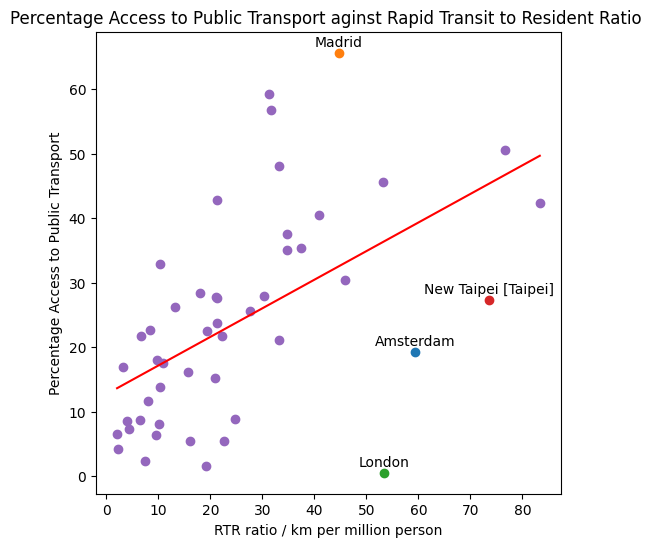

In [4]:
## 2a. Fit a line using OLS
from statsmodels.stats.outliers_influence import OLSInfluence

# n=48
cleaned = den_acc_pt[den_acc_pt['Percentage Access to Public Transport'].notna() &
                     den_acc_pt['Rapid Transit to Resident Ratio (RTR)'].notna()]

X = sm.add_constant(cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y = cleaned[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()

# Find anomalous points using Cook's distance
influence = OLSInfluence(model)
(c, p) = influence.cooks_distance

threshold = 4/len(cleaned.index)
anomaly = cleaned[c > threshold]
non_anomaly = cleaned[~(c > threshold)]

# Sort OLS X, y values 
sorted_cleaned = cleaned.sort_values(by='Rapid Transit to Resident Ratio (RTR)')
X_sorted = sm.add_constant(sorted_cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y_line = model.predict(X_sorted)

# 2b. Scatter plot (access vs RTR) + OLS plot
fig, ax = plt.subplots(figsize=(6,6))
for city, row in anomaly.iterrows():
    ax.scatter(row.iloc[2], row.iloc[1])
    ax.text(row.iloc[2], row.iloc[1]+1, city, ha='center')

ax.scatter(non_anomaly['Rapid Transit to Resident Ratio (RTR)'], non_anomaly['Percentage Access to Public Transport'])
ax.plot(sorted_cleaned['Rapid Transit to Resident Ratio (RTR)'], y_line, color='red')

ax.set_title("Percentage Access to Public Transport aginst Rapid Transit to Resident Ratio ")
ax.set_xlabel("RTR ratio / km per million person")
ax.set_ylabel("Percentage Access to Public Transport")
plt.show()

# RTR ratio moves with percentage access, with a few outliers indicating 
# some cities are unusually efficient (high access + low RTR ratio), or inefficient (low access + high RTR ratio)
# Outcome depends more on systematic planning

# https://www.oliverwymanforum.com/mobility/urban-mobility-readiness-index-2023/amsterdam.html (Amsterdam)

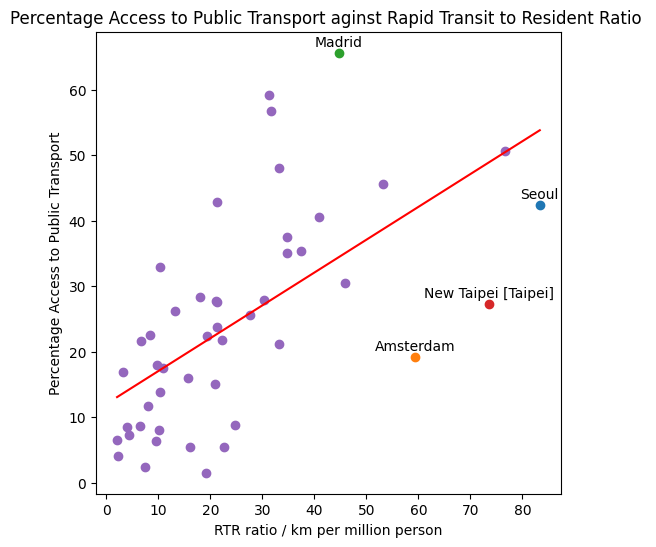

In [5]:
# Drop London (near 0 access to PT, impossible)
cleaned = cleaned.drop('London')

# 2c. REPEAT flagging anomalous points + plot regression

X = sm.add_constant(cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y = cleaned[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()

influence = OLSInfluence(model)
(c, p) = influence.cooks_distance

threshold = 4/len(cleaned.index)
anomaly = cleaned[c > threshold]
non_anomaly = cleaned[~(c > threshold)]

# Sort OLS X, y values
sorted_cleaned = cleaned.sort_values(by='Rapid Transit to Resident Ratio (RTR)')
X_sorted = sm.add_constant(sorted_cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y_line = model.predict(X_sorted)

# Plot scatter

fig, ax = plt.subplots(figsize=(6,6))
for city, row in anomaly.iterrows():
    ax.scatter(row.iloc[2], row.iloc[1])
    ax.text(row.iloc[2], row.iloc[1]+1, city, ha='center')

ax.scatter(non_anomaly['Rapid Transit to Resident Ratio (RTR)'], non_anomaly['Percentage Access to Public Transport'])
ax.plot(sorted_cleaned['Rapid Transit to Resident Ratio (RTR)'], y_line, color='red')

ax.set_title("Percentage Access to Public Transport aginst Rapid Transit to Resident Ratio ")
ax.set_xlabel("RTR ratio / km per million person")
ax.set_ylabel("Percentage Access to Public Transport")
plt.show()

# Anomalous points are the same, with Seoul as an addition (n=4). Model is more or less stable


In [6]:
# 3a. Stratify cities (access below OLS, access above OLS)
cleaned['residual_acc'] = cleaned['Percentage Access to Public Transport']-model.predict(X)

df_join = df[['Pedestrian Streets per capita', 'Modal split (Passenger) - by trips - Car (2017)', 
              'Oxford Economics Global Cities Index (Quality of Life)', 'Oxford Economics Global Cities Index (Governance)']]
cleaned = df_join.join(cleaned, how='right')

cleaned['group'] = ['Above expected' if r>0 else 'Below expected' for r in cleaned['residual_acc']]
cleaned.dropna(subset=['Oxford Economics Global Cities Index (Quality of Life)'], inplace=True)

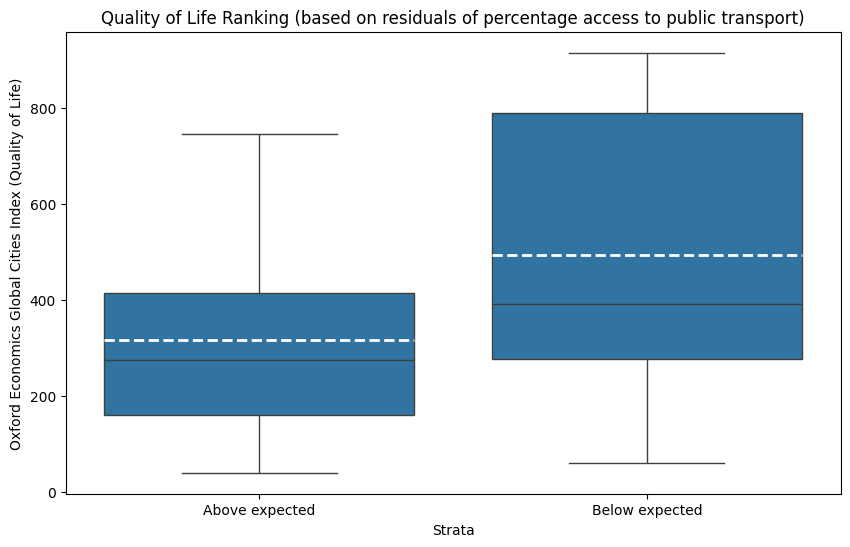

In [7]:
# 3b. Explore governance score (rank) in both strata

fig, ax = plt.subplots(figsize=(10,6))

#print(cleaned[cleaned['group']=='Below expected']['Oxford Economics Global Cities Index (Quality of Life)'].sort_values())

# Boxplot for both strata
sns.boxplot(data=cleaned, x='group', y='Oxford Economics Global Cities Index (Quality of Life)', 
            showmeans=True, meanline=True, meanprops={'color': 'white', 'lw': 2})
ax.set_title('Quality of Life Ranking (based on residuals of percentage access to public transport)')
ax.set_xlabel('Strata')
plt.show()

# Cities above OLS line overall rank higher (mean, median, range). 
# The lowest ranking (outlier disregarded) is the upper bound of bottom 25% of its counterpart 
# Cities below OLS line have higher variance, implying some highly livable cities rely on a transport landscape that does not necessarily involve public transport
# This also suggests systematic factors in lower ranking cities that results in lower transport access
# Boxplot show overall high within-group variance

# Despite lower median (<300) in cities above OLS line, the bottom 50% of the cities vary greatly in ranking with rankings reaching 700+
# This could suggest strong institutional support for efficient urban mobility that operates on necessity, often common in hyper-dense developing cities with lower systemic quality of life

In [8]:
# 3c. Wilcoxon Ranked Sum Test 
from scipy import stats

above = cleaned[cleaned['group']== 'Above expected']['Oxford Economics Global Cities Index (Quality of Life)']
below = cleaned[cleaned['group']== 'Below expected']['Oxford Economics Global Cities Index (Quality of Life)']

u, p = stats.mannwhitneyu(above, below)
print(f"Mann-Whitney P-value: {p:.4f}")
print(f"U statistic: {u}")

# 3d. Welch T test
t, p = stats.ttest_ind(above, below, equal_var=False)
print("T test p value: ", p)
print(f"t statistic: {t}")

# Wilcoxon Rank Sum Test exhibits strong evidence in difference between rankings of both strata 
# Result of this non-parametric test is not dependent on normally distributed data
# Welch t test results show high significance in difference of means of rankings, suggesting urban livability as a strong driver 
# for public transportation accessibility 

Mann-Whitney P-value: 0.0506
U statistic: 175.0
T test p value:  0.02305600355322938
t statistic: -2.363962958262238


In [ ]:
# 3e. Effect size
 
m1 = above.mean()
m2 = below.mean()
n1 = above.shape[0]
n2 = below.shape[0]

s1, s2 = above.var(ddof=1), below.var(ddof=1)
std = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))

d = (m1-m2)/std
print(f"Cohen d:", d)

# Moderate effect size (|d|=0.69) of quality of life between cities above OLS and below OLS regimes. 
# Technically speaking, the mean ranking of two strata vary by 0.69 std  

Cohen d: -0.6970946456878035
